# Voting Classifier — Hard, Soft, and Weighted Voting on Iris
A **Voting Classifier** combines multiple classifiers and makes predictions by aggregating their votes.

| Mode | How it works | When to use |
|------|-------------|-------------|
| **Hard voting** | Each classifier votes a class; majority wins | When models are well-calibrated |
| **Soft voting** | Average predicted probabilities; highest wins | Better — uses confidence, not just class label |
| **Weighted voting** | Some models get more say | When one model is clearly stronger |


## Step 1: Load Iris Dataset

In [6]:
import pandas as pd
df = pd.read_csv(r'd:\PENDRIVE 32 GB\Game\AI_PROJECTS\Machine Learning\100-days-of-machine-learning-main\day59-classification-metrics\Iris.csv')

In [7]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa


In [8]:
# remove Id col
df = df.iloc[:,1:]

In [9]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Step 2: Encode Species
`LabelEncoder` → setosa=0, versicolor=1, virginica=2

In [10]:
# Label encode Species
from sklearn.preprocessing import LabelEncoder

In [11]:
encoder = LabelEncoder()

In [12]:
df['Species'] = encoder.fit_transform(df['Species'])

In [13]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Step 3: Visualise Pairplot
See how well the features separate the 3 species — useful to judge if voting will help.

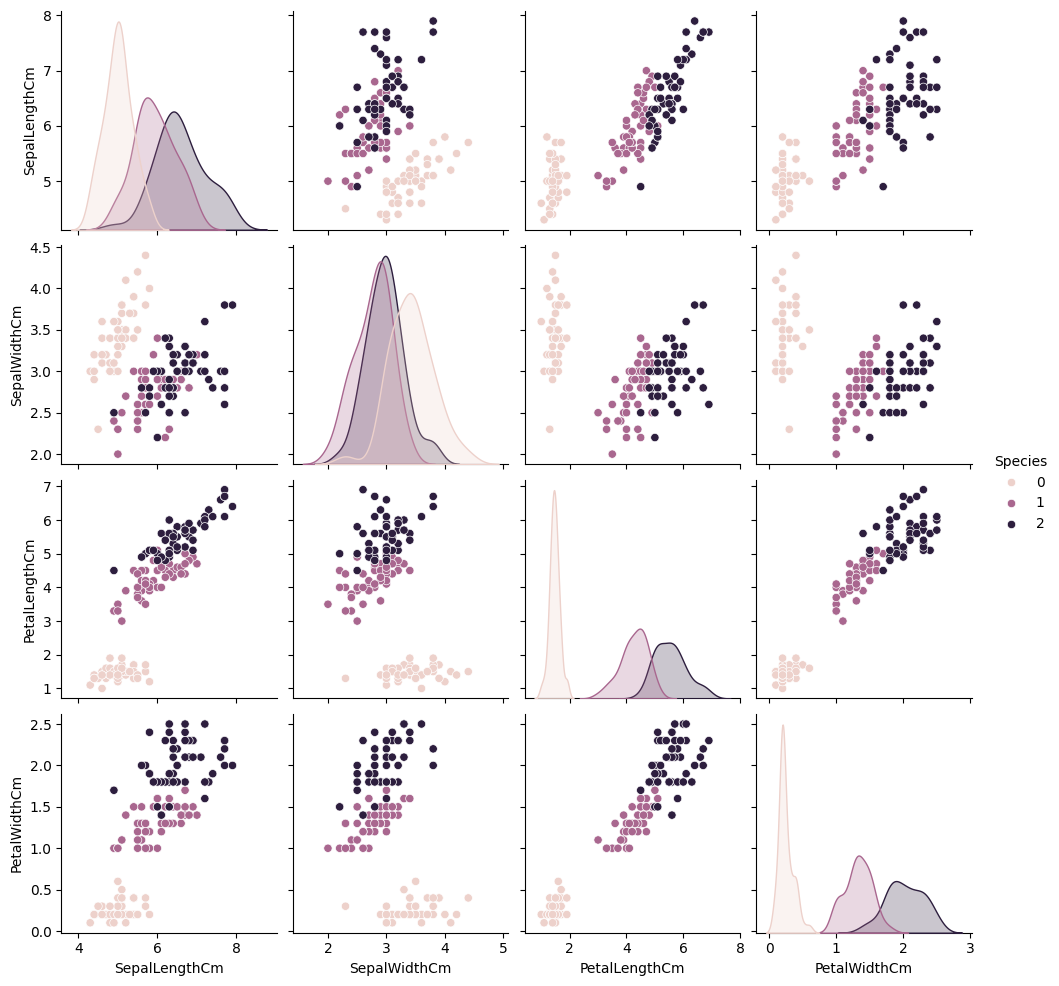

In [14]:
import seaborn as sns
sns.pairplot(df,hue='Species')

## Step 4: Filter and Prepare Features
Keep the first 2 features for easy visualisation. `X` = first 2 columns, `y` = last column.

In [15]:
new_df = df[df['Species'] != 0][['SepalLengthCm','SepalWidthCm','Species']]

In [16]:
new_df.head()

,SepalLengthCm,SepalWidthCm,Species
50,7.0,3.2,1
51,6.4,3.2,1
52,6.9,3.1,1
53,5.5,2.3,1
54,6.5,2.8,1


In [17]:
new_df.shape

(100, 3)

In [18]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

## Step 5: Define 3 Diverse Base Classifiers
Using three fundamentally different algorithms:
- `LogisticRegression` — linear boundary, probabilistic
- `RandomForestClassifier` — ensemble of trees, non-linear
- `KNeighborsClassifier` — distance-based, non-parametric


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [20]:
clf1 = LogisticRegression()
clf2 = RandomForestClassifier()
clf3 = KNeighborsClassifier()

In [21]:
estimators = [('lr',clf1),('rf',clf2),('knn',clf3)]

## Step 6: Cross-Validate Each Classifier Individually
10-fold CV accuracy for each model. The Voting Classifier should beat all of them.

In [22]:
for estimator in estimators:
    x = cross_val_score(estimator[1],X,y,cv=10,scoring='accuracy')
    print(estimator[0],np.round(np.mean(x),2))

lr 0.81
rf 0.72
knn 0.76


In [23]:
from sklearn.ensemble import VotingClassifier

---
## Hard Voting
Each classifier predicts a class label. The class with the most votes wins.
Example: LR→1, RF→2, KNN→1 → final prediction = **1** (2 votes)


## Hard Voting

In [24]:
vc = VotingClassifier(estimators=estimators,voting='hard')
x = cross_val_score(vc,X,y,cv=10,scoring='accuracy')
print(np.round(np.mean(x),2))

0.77


---
## Soft Voting
Each classifier outputs class **probabilities** (must support `predict_proba`).
Probabilities are averaged; the class with the highest average probability wins.
**Soft voting is almost always better than hard voting** — it uses the confidence of each vote.
Example: LR→[0.1, 0.8, 0.1], RF→[0.05, 0.9, 0.05], KNN→[0.2, 0.7, 0.1] → avg→[0.12, 0.8, 0.08] → class 1


## Soft Voting

In [25]:
vc1 = VotingClassifier(estimators=estimators,voting='soft')
x = cross_val_score(vc1,X,y,cv=10,scoring='accuracy')
print(np.round(np.mean(x),2))

0.75


---
## Weighted Voting
Give different weights to each classifier's vote.
`weights=[i, j, k]` → LR gets weight i, RF gets weight j, KNN gets weight k.
Try all 27 combinations of weights 1–3. Best combination = best accuracy.


## Weighted Voting

In [26]:
for i in range(1,4):
    for j in range(1,4):
        for k in range(1,4):
            vc = VotingClassifier(estimators=estimators,voting='soft',weights=[i,j,k])
            x = cross_val_score(vc,X,y,cv=10,scoring='accuracy')
            print("for i={},j={},k={}".format(i,j,k),np.round(np.mean(x),2))
            

for i=1,j=1,k=1 0.77
for i=1,j=1,k=2 0.77
for i=1,j=1,k=3 0.76
for i=1,j=2,k=1 0.76
for i=1,j=2,k=2 0.76
for i=1,j=2,k=3 0.76
for i=1,j=3,k=1 0.73
for i=1,j=3,k=2 0.75
for i=1,j=3,k=3 0.76
for i=2,j=1,k=1 0.77
for i=2,j=1,k=2 0.77
for i=2,j=1,k=3 0.77
for i=2,j=2,k=1 0.77
for i=2,j=2,k=2 0.76
for i=2,j=2,k=3 0.77
for i=2,j=3,k=1 0.77
for i=2,j=3,k=2 0.75
for i=2,j=3,k=3 0.77
for i=3,j=1,k=1 0.79
for i=3,j=1,k=2 0.79
for i=3,j=1,k=3 0.79
for i=3,j=2,k=1 0.78
for i=3,j=2,k=2 0.77
for i=3,j=2,k=3 0.77
for i=3,j=3,k=1 0.77
for i=3,j=3,k=2 0.77
for i=3,j=3,k=3 0.77


---
## Voting with the Same Algorithm — Different Hyperparameters
Instead of diverse models, use **one algorithm (SVM) with different C values** (regularisation strength).
- Small C → more regularisation, simpler boundary
- Large C → less regularisation, fits training data more tightly
Combining different strengths smooths out each one's weaknesses.


## Classifiers of Same Algo

In [27]:
from sklearn.svm import SVC

In [28]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=2)

svm1 = SVC(probability=True, kernel='poly', degree=1)
svm2 = SVC(probability=True, kernel='poly', degree=2)
svm3 = SVC(probability=True, kernel='poly', degree=3)
svm4 = SVC(probability=True, kernel='poly', degree=4)
svm5 = SVC(probability=True, kernel='poly', degree=5)

estimators = [('svm1',svm1),('svm2',svm2),('svm3',svm3),('svm4',svm4),('svm5',svm5)]

for estimator in estimators:
    x = cross_val_score(estimator[1],X,y,cv=10,scoring='accuracy')
    print(estimator[0],np.round(np.mean(x),2))

svm1 0.85
svm2 0.85
svm3 0.89
svm4 0.81
svm5 0.86


In [29]:
vc1 = VotingClassifier(estimators=estimators,voting='soft')
x = cross_val_score(vc1,X,y,cv=10,scoring='accuracy')
print(np.round(np.mean(x),2))

0.93
